# Keras quickstart

We recommend running this example in Colab's GPU runtime. It will run on Jax, TensorFlow or PyTorch, simply change the line below.

In [1]:
import os
#os.environ["KERAS_BACKEND"] = "jax"  # Or "torch" or "tensorflow"

## Train an MNIST classifier with a mini ResNet model

In [2]:
import keras
from keras.datasets import mnist
from keras import layers

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255., x_test / 255.

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu")(inputs)
x = layers.Conv2D(64, 3, activation="relu")(x)
residual = x = layers.MaxPooling2D(3)(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = x + residual

x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="mini_resnet")

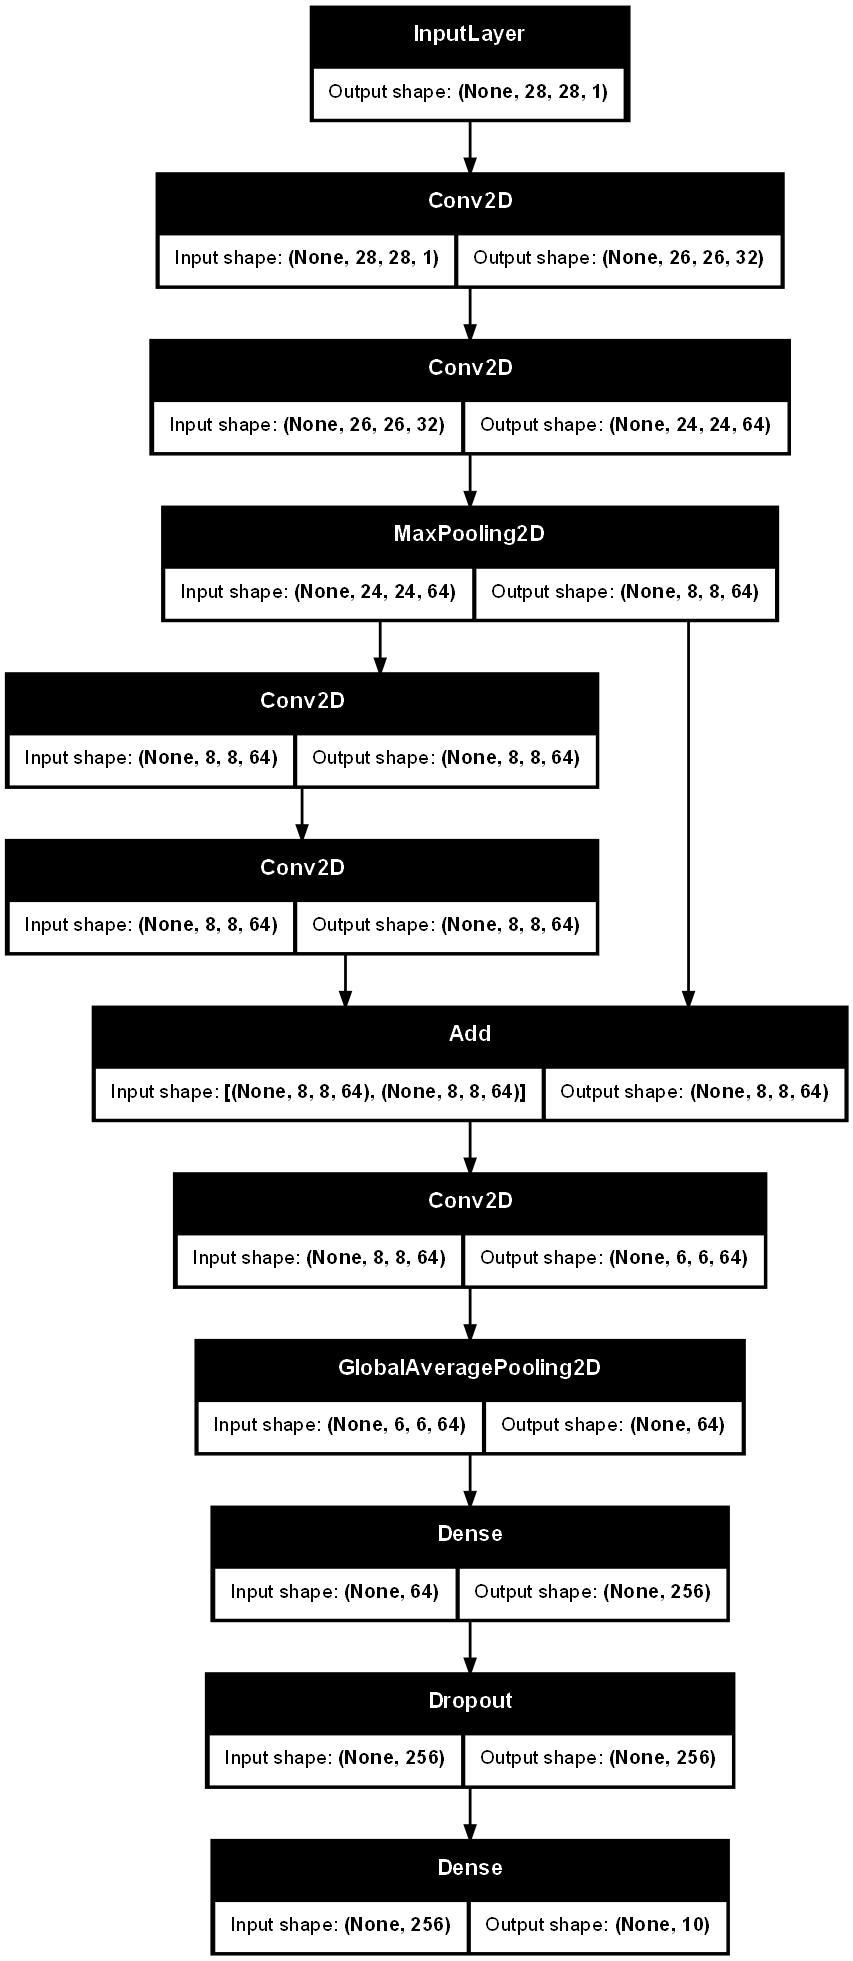

In [4]:
keras.utils.plot_model(model, "mini_resnet.png", dpi=100, show_shapes=True)

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=20)
model.evaluate(x_test, y_test)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - accuracy: 0.7338 - loss: 0.7464
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9755 - loss: 0.0837
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9853 - loss: 0.0510
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9876 - loss: 0.0420
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9898 - loss: 0.0339
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9922 - loss: 0.0283
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9928 - loss: 0.0227
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9932 - loss: 0.0214
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9951 - loss: 0.0176
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9952 - loss: 0.0167
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9956 - loss: 0.0143
Epoch 12

[0.03911471739411354, 0.9905999898910522]